# Social media Mining 
Submitted by - Arpita Lonakadi 
U.ID - 2001279487 

### Step 1 : Data Loading

In [28]:
#Importing the dataset and checking columns 

import pandas as pd
import json

# Load training dataset
with open('/Users/arpitalonakadi/Downloads/z639_assignment1_training.json', 'r') as f:
    train_data = [json.loads(line) for line in f]

# Convert the training dataset to a DataFrame
df_train = pd.DataFrame(train_data)

# Display the first few rows of the DataFrame
print(df_train.head())

# Display column names and data types
print(df_train.info())


                                                text  \
0  WTF, y'all never made MRE fart balloons in the...   
1  No apologies !! McCall has balls !  Ccp is not...   
2  What ever you need to tell yourself to sleep a...   
3                   @exZACKly @CBSNews Fuck off Nazi   
4  Texas is a republican sponsored killing ground...   

                                      parent_comment  \
0                                               None   
1                                               None   
2  I wonder how many undercover agents will be go...   
3  @NCmylo @CBSNews Lol.  Stop choosing to be an ...   
4                                               None   

                                       article_title  \
0  Triangular UFO hovers over California military...   
1  China sentences elderly US citizen to life in ...   
2  Jan. 6 defendant who put foot on desk in Pelos...   
3  19-year-old Missouri man arrested in U-Haul cr...   
4  At Least 8 Killed After Driver Plows Car In

In [29]:
#display top 20 rows of dataframe
df_train.head(20)

,text,parent_comment,article_title,article_url,platform,platform_id,composite_toxic
0,"WTF, y'all never made MRE fart balloons in the...",None,Triangular UFO hovers over California military...,https://www.dailymail.co.uk/news/article-12112...,reddit,jlcm021,"[[False, 74], [True, 323], [False, 1028], [Fal..."
1,No apologies !! McCall has balls ! Ccp is not...,None,China sentences elderly US citizen to life in ...,https://www.cnn.com/2023/05/15/china/china-jai...,youtube,Ugws8gNW7eJyE9VHeM14AaABAg,"[[False, 216], [False, 197], [False, 1039], [F..."
2,What ever you need to tell yourself to sleep a...,I wonder how many undercover agents will be go...,Jan. 6 defendant who put foot on desk in Pelos...,https://www.cbsnews.com/news/richard-barnett-j...,youtube,UgxHlqwNcVssLHUr4yF4AaABAg.9q7kOunSlu-9q7lHH4he6S,"[[True, 192], [True, 193], [True, 260], [True,..."
3,@exZACKly @CBSNews Fuck off Nazi,@NCmylo @CBSNews Lol. Stop choosing to be an ...,19-year-old Missouri man arrested in U-Haul cr...,https://www.cbsnews.com/news/u-haul-crash-lafa...,twitter,1661025155047637000,"[[True, 92], [False, 218], [True, 69], [True, ..."
4,Texas is a republican sponsored killing ground...,None,At Least 8 Killed After Driver Plows Car Into ...,https://www.nytimes.com/2023/05/07/us/car-pede...,youtube,UgwpAfn9RIV0cHfhp4R4AaABAg,"[[False, 56], [True, 207], [False, 218], [Fals..."
5,"I get that calling the rapporteur a ""fake job""...",None,Poilievre declined meeting with Johnston on fo...,https://www.cbc.ca/news/politics/johnston-meet...,reddit,jkmp2qz,"[[False, 25], [False, 255], [False, 316], [Fal..."
6,"Ok, so when are people getting arrested for l...",None,"Durham finds DOJ, FBI 'failed to uphold' missi...",https://www.foxnews.com/politics/durham-doj-fb...,youtube,Ugw_ljJF_z6Lhs_EWE14AaABAg,"[[False, 27], [False, 98], [False, 198], [Fals..."
7,@noon4s @AndrewJakeMIII @AP @elonmusk MAGA mor...,@AndrewJakeMIII @chzhedz150412 @AP @elonmusk W...,"Turkey's elections for presidency, parliament ...",https://apnews.com/article/turkey-elections-er...,twitter,1657624414307901443,"[[True, 120], [True, 199], [True, 1021], [True..."
8,yeah i doubt that's false. Biden wants Drag qu...,None,Erdogan accuses Turkish opposition of working ...,https://www.reuters.com/world/middle-east/fina...,youtube,UgzYGcIw_fskfi1zoIp4AaABAg,"[[True, 108], [True, 48], [False, 55], [True, ..."
9,">\t(unless signed contract exists, which is wh...","They wouldn't rip it back retroactively, too m...",What's in the debt ceiling deal — and what's not,https://www.cbsnews.com/news/whats-in-2023-deb...,reddit,jm2tisv,"[[False, 104], [False, 99], [False, 52], [Fals..."


In [30]:
# Check for missing values
print(df_train.isnull().sum())

text                  0
parent_comment     2598
article_title         0
article_url           0
platform              0
platform_id           0
composite_toxic       0
dtype: int64


### Step 2 : Data preprocessing (cleaning, steming, stopwords, lematizing, emoji handling) 

In [31]:
#creating a new column i.e toxic label that takes into consideration all annotations from different workers from the composite toxic column and creates a binary label.
#it uses majority voting to assign a binary label (1 for toxic, 0 for non-toxic).
# It sums the True (toxic) labels from the composite_toxic field and assigns a label based on whether the count exceeds 2.

import pandas as pd

# Function to process toxicity label using majority voting
def label_toxicity(composite_toxic):
    true_count = sum([label for label, _ in composite_toxic])  # Count the number of 'true' (toxic) labels
    return 1 if true_count > 2 else 0  # If more than 2 workers say it's toxic, label it as toxic (1), otherwise non-toxic (0)

# Apply majority voting to create a binary toxic label
df_train['toxic_label'] = df_train['composite_toxic'].apply(label_toxicity)

# Check the newly created toxic_label column
print(df_train[['composite_toxic', 'toxic_label']].head())

                                     composite_toxic  toxic_label
0  [[False, 74], [True, 323], [False, 1028], [Fal...            0
1  [[False, 216], [False, 197], [False, 1039], [F...            0
2  [[True, 192], [True, 193], [True, 260], [True,...            1
3  [[True, 92], [False, 218], [True, 69], [True, ...            1
4  [[False, 56], [True, 207], [False, 218], [Fals...            0


In [32]:
!pip install emoji
!pip install vaderSentiment

In [33]:
#performing steps of stemming, stopwords, lemmatization and also identifying emojis and adding special column for emoji score which maps positive emojis to +1 socre and 
#toxic imojis to -1 score. Also adding vander score for each comment to use for feature extraction steps and model training 

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import emoji
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('punkt')

# Initialize stopwords, stemmer, and VADER sentiment analyzer
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()
analyzer = SentimentIntensityAnalyzer()

# Predefined emoji sentiment score dictionary using demojized format
emoji_sentiment_dict = {
    "smilingfacewithsmilingeyes": 1,
    "neutralface": 0,
    "angryface": -1,
    "facewithtearsofjoy": 1,
    "thumbsup": 1,
    "thumbsdown": -1
}

# Function to clean text and compute emoji sentiment score and VADER sentiment score
def clean_text_with_sentiment_scores(text):
    # Step 1: Convert text to lowercase
    text = text.lower()

    # Step 2: Remove user mentions (e.g., @username)
    text = re.sub(r'@\w+[^ ]*', '', text)

    # Step 3: Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Step 4: Convert emojis into text descriptions
    text = emoji.demojize(text)

    # Step 5: Remove punctuation and special characters
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Step 6: Remove new line characters
    text = text.replace('\n', ' ').replace('\t', ' ')

    # Step 7: Remove stopwords
    words = [word for word in text.split() if word not in stop_words]

    # Step 8: Apply stemming
    words = [ps.stem(word) for word in words]

    # Join the words back into a single string
    cleaned_text = " ".join(words)

    # Step 9: Calculate emoji sentiment score
    emoji_score = sum([emoji_sentiment_dict.get(f"{word}", 0) for word in words])

    # Step 10: Calculate VADER sentiment score (using compound score)
    vader_score = analyzer.polarity_scores(text)['compound']

    return cleaned_text, emoji_score, vader_score

# Apply the cleaning and sentiment score extraction to the dataset
df_train['cleaned_text'], df_train['emoji_score'], df_train['vader_score'] = zip(*df_train['text'].apply(clean_text_with_sentiment_scores))

# Check the cleaned text, emoji scores, and vader scores
print(df_train[['text', 'cleaned_text', 'emoji_score', 'vader_score']].head(20))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/arpitalonakadi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/arpitalonakadi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                                 text  \
0   WTF, y'all never made MRE fart balloons in the...   
1   No apologies !! McCall has balls !  Ccp is not...   
2   What ever you need to tell yourself to sleep a...   
3                    @exZACKly @CBSNews Fuck off Nazi   
4   Texas is a republican sponsored killing ground...   
5   I get that calling the rapporteur a "fake job"...   
6   Ok,  so when are people getting arrested for l...   
7   @noon4s @AndrewJakeMIII @AP @elonmusk MAGA mor...   
8   yeah i doubt that's false. Biden wants Drag qu...   
9   >\t(unless signed contract exists, which is wh...   
10  Cruise missiles aren't that hard to shoot down...   
11  How is this idiot still in office?  Georgia yo...   
12          @KariLake @NBCNews It’s the guns bitch!!!   
13  If you're wondering how such an august body ca...   
14  @MuellerSheWrote @7Veritas4 Cue Truth Sociopat...   
15  Hi seenonworldnews_bot,\n\nWe've found **1 sou...   
16  @AP And, in the process, co

### Step 3 : EDA on cleaned data 

In [34]:
!pip install wordcloud


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/arpitalonakadi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/var/folders/j7/dszb7wp10w9fqy2ly1kv4b3c0000gn/T/ipykernel_93265/1080425827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='toxic_label', data=df_train, palette='Set2')


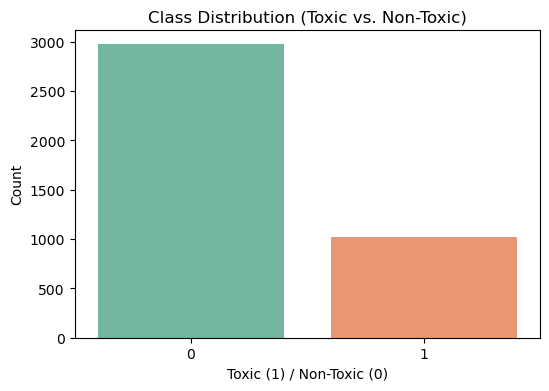

In [35]:
#importing necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from collections import Counter

# Download necessary resources
nltk.download('punkt')

# Step 1: Class imbalance analysis
plt.figure(figsize=(6, 4))
sns.countplot(x='toxic_label', data=df_train, palette='Set2')
plt.title("Class Distribution (Toxic vs. Non-Toxic)")
plt.xlabel("Toxic (1) / Non-Toxic (0)")
plt.ylabel("Count")
plt.show()

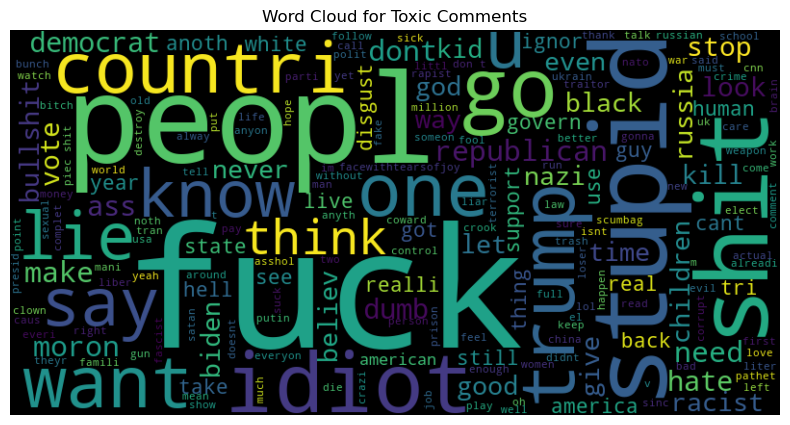

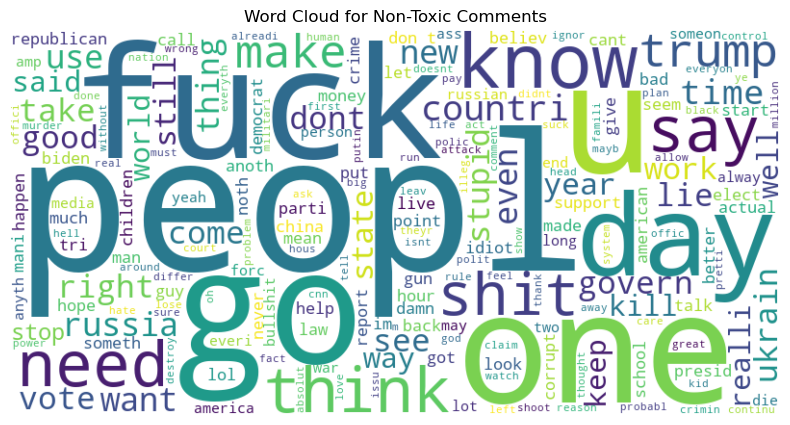

In [36]:
 #Step 2: Word Cloud for toxic vs non-toxic comments
toxic_comments = " ".join(df_train[df_train['toxic_label'] == 1]['cleaned_text'].values)
non_toxic_comments = " ".join(df_train[df_train['toxic_label'] == 0]['cleaned_text'].values)

# Generate word cloud for toxic comments
wordcloud_toxic = WordCloud(width=800, height=400, background_color='black').generate(toxic_comments)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_toxic, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Toxic Comments")
plt.show()

# Generate word cloud for non-toxic comments
wordcloud_non_toxic = WordCloud(width=800, height=400, background_color='white').generate(non_toxic_comments)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_non_toxic, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Non-Toxic Comments")
plt.show()


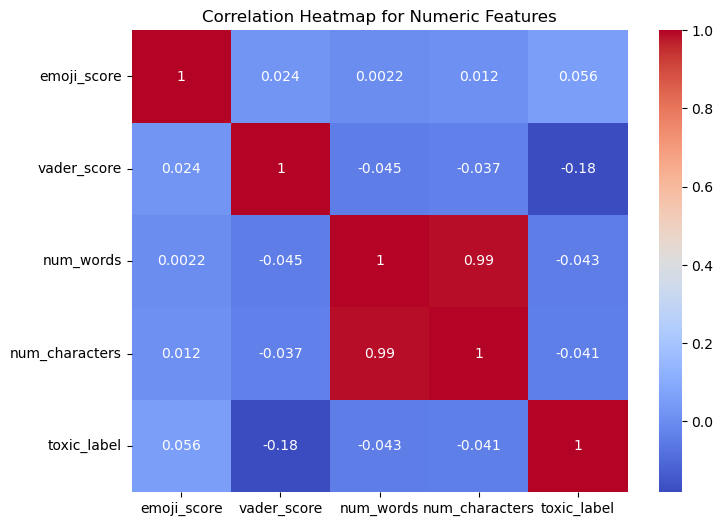

In [37]:
# Step 3: Correlation heatmap (for numeric features like emoji score, vader score, and comment length)
df_train['num_words'] = df_train['cleaned_text'].apply(lambda x: len(nltk.word_tokenize(x)))
df_train['num_characters'] = df_train['cleaned_text'].apply(len)

# Correlation heatmap including vader_score, emoji_score, num_words, and num_characters
plt.figure(figsize=(8, 6))
sns.heatmap(df_train[['emoji_score', 'vader_score', 'num_words', 'num_characters', 'toxic_label']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap for Numeric Features")
plt.show()

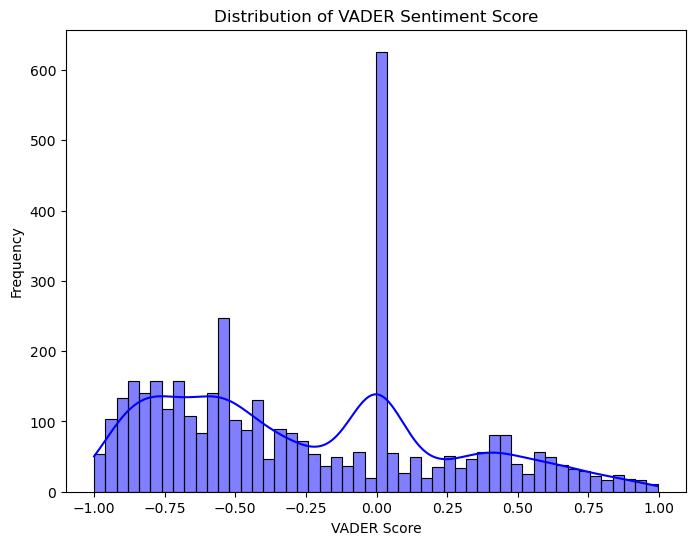

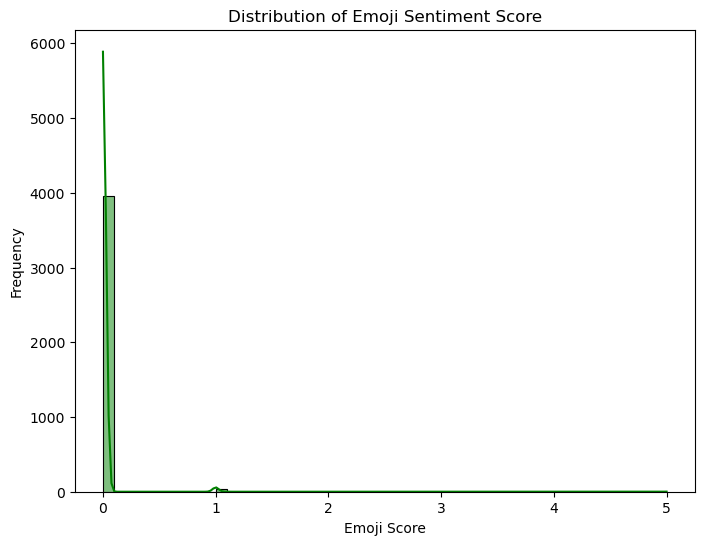

In [38]:

# Step 4: Distribution of VADER score and emoji score
plt.figure(figsize=(8, 6))
sns.histplot(df_train['vader_score'], bins=50, color='blue', kde=True)
plt.title("Distribution of VADER Sentiment Score")
plt.xlabel("VADER Score")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(df_train['emoji_score'], bins=50, color='green', kde=True)
plt.title("Distribution of Emoji Sentiment Score")
plt.xlabel("Emoji Score")
plt.ylabel("Frequency")
plt.show()


/var/folders/j7/dszb7wp10w9fqy2ly1kv4b3c0000gn/T/ipykernel_93265/506243056.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='toxic_label', y='vader_score', data=df_train, palette='Set2')


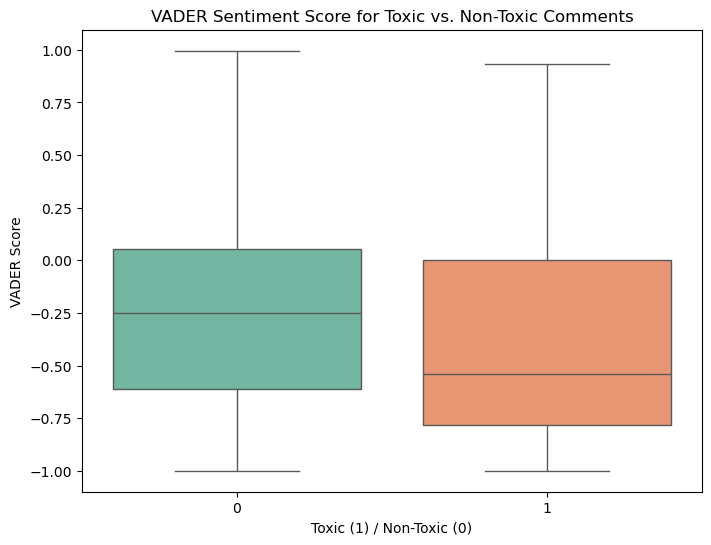

/var/folders/j7/dszb7wp10w9fqy2ly1kv4b3c0000gn/T/ipykernel_93265/506243056.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='toxic_label', y='emoji_score', data=df_train, palette='Set3')


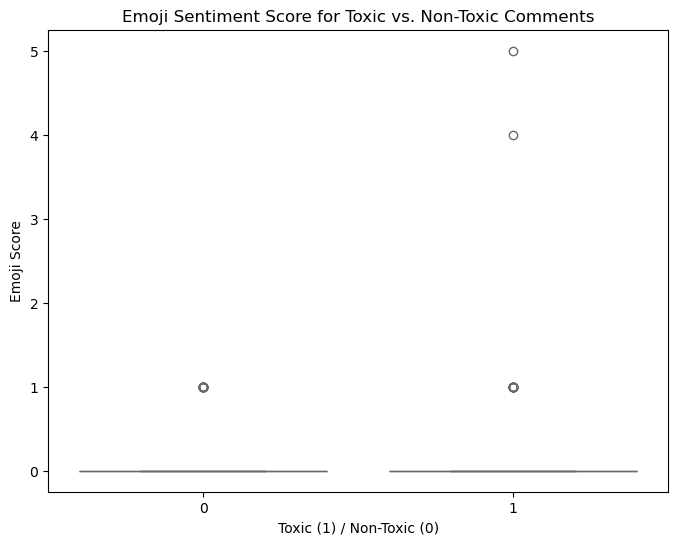

In [39]:

# Step 5: Analyze VADER and Emoji Score for Toxic vs. Non-Toxic Comments
plt.figure(figsize=(8, 6))
sns.boxplot(x='toxic_label', y='vader_score', data=df_train, palette='Set2')
plt.title("VADER Sentiment Score for Toxic vs. Non-Toxic Comments")
plt.xlabel("Toxic (1) / Non-Toxic (0)")
plt.ylabel("VADER Score")
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='toxic_label', y='emoji_score', data=df_train, palette='Set3')
plt.title("Emoji Sentiment Score for Toxic vs. Non-Toxic Comments")
plt.xlabel("Toxic (1) / Non-Toxic (0)")
plt.ylabel("Emoji Score")
plt.show()


In [40]:

# Step 6: Most Common Words in Toxic and Non-Toxic Comments
toxic_words = Counter(" ".join(df_train[df_train['toxic_label'] == 1]['cleaned_text']).split())
non_toxic_words = Counter(" ".join(df_train[df_train['toxic_label'] == 0]['cleaned_text']).split())

print("Top 20 most common words in toxic comments:")
print(toxic_words.most_common(20))

print("\nTop 20 most common words in non-toxic comments:")
print(non_toxic_words.most_common(20))

Top 20 most common words in toxic comments:
[('fuck', 262), ('peopl', 127), ('shit', 102), ('like', 99), ('get', 89), ('stupid', 88), ('idiot', 77), ('go', 75), ('trump', 66), ('one', 58), ('want', 56), ('countri', 54), ('your', 53), ('say', 48), ('know', 47), ('lie', 47), ('think', 44), ('need', 43), ('moron', 43), ('republican', 43)]

Top 20 most common words in non-toxic comments:
[('peopl', 341), ('like', 302), ('get', 253), ('go', 243), ('fuck', 216), ('us', 208), ('one', 207), ('day', 195), ('would', 190), ('know', 187), ('think', 180), ('need', 168), ('shit', 168), ('say', 167), ('make', 160), ('trump', 159), ('time', 156), ('countri', 150), ('dont', 147), ('want', 141)]


### Step 4 : Feature extraction

In [41]:
#incorporating feature extraction using vander scores, tf-idf vectorization and emoji scores to get appropriate featureset for machine learning model 

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np

# Initialize the TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Transform the cleaned text data into TF-IDF features
X_tfidf = tfidf.fit_transform(df_train['cleaned_text'])

# Combine the TF-IDF matrix with emoji_score and vader_score
emoji_vader_scores = df_train[['emoji_score', 'vader_score']].values
X_combined = np.hstack([X_tfidf.toarray(), emoji_vader_scores])

# Extract the labels
y_train = df_train['toxic_label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_train, test_size=0.2, random_state=42)

# Print the shape of the resulting feature matrix
print(f"TF-IDF + Emoji + VADER Feature matrix shape (Train): {X_train.shape}")
print(f"TF-IDF + Emoji + VADER Feature matrix shape (Test): {X_test.shape}")

TF-IDF + Emoji + VADER Feature matrix shape (Train): (3200, 5002)
TF-IDF + Emoji + VADER Feature matrix shape (Test): (800, 5002)


### Step 5 : Model build 

In [42]:
!pip install xgboost

In [43]:
# building 4 models selected based on eda which are most likely to give optimal results 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Function to evaluate each model
def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Train the model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    # Print results
    print(f"Model: {model.__class__.__name__}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Confusion Matrix: \n{conf_matrix}")
    print('-' * 50)

# List of models to evaluate (excluding MultinomialNB)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Assuming X_train, X_test, y_train, y_test are already split and available (TF-IDF + Vader + Emoji scores)

#Model Evaluation 
# Loop through models and evaluate
for model_name, model in models.items():
    evaluate_model(model, X_train, X_test, y_train, y_test)

Model: LogisticRegression
Accuracy: 0.7638
Precision: 0.6909
Recall: 0.1810
F1-Score: 0.2868
Confusion Matrix: 
[[573  17]
 [172  38]]
--------------------------------------------------
Model: RandomForestClassifier
Accuracy: 0.7575
Precision: 0.7222
Recall: 0.1238
F1-Score: 0.2114
Confusion Matrix: 
[[580  10]
 [184  26]]
--------------------------------------------------
Model: SVC
Accuracy: 0.7562
Precision: 0.6596
Recall: 0.1476
F1-Score: 0.2412
Confusion Matrix: 
[[574  16]
 [179  31]]
--------------------------------------------------


/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:48:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model: XGBClassifier
Accuracy: 0.7550
Precision: 0.5648
Recall: 0.2905
F1-Score: 0.3836
Confusion Matrix: 
[[543  47]
 [149  61]]
--------------------------------------------------


### Step 6 : Model selection and Hyper parameter tuning

In [44]:
#based on model evaluation results, xgboost gives the best prescision and recall, thus it is selected for further finetuning for optimal results

import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Step 1: Define the XGBoost model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Step 2: Define parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'subsample': [0.7, 1.0]
}

print("Model and parameter grid setup complete.")

Model and parameter grid setup complete.


In [45]:
# Step 3: Perform Grid Search for hyperparameter tuning
grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Step 4: Print the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:49:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:49:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:49:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:49:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packa

Best Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.7}


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       590
           1       0.56      0.33      0.41       210

    accuracy                           0.76       800
   macro avg       0.68      0.62      0.63       800
weighted avg       0.73      0.76      0.73       800

Confusion Matrix:
[[536  54]
 [141  69]]


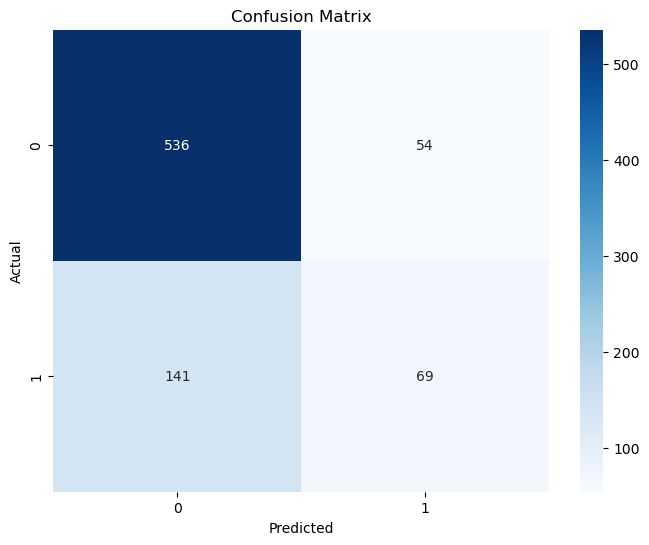

In [46]:
# Step 1: Train the final XGBoost model using the best hyperparameters
best_xgb = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.2,
    max_depth=5,
    colsample_bytree=1.0,
    subsample=0.7,
    eval_metric='mlogloss'
)

# Step 2: Train the model on the training data
best_xgb.fit(X_train, y_train)

# Step 3: Make predictions on the test data
y_pred = best_xgb.predict(X_test)

# Step 4: Evaluate the model using classification metrics
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Ploting confusion matrix for better visualization
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Threshold: 0.3
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.62      0.72       590
           1       0.40      0.70      0.51       210

    accuracy                           0.64       800
   macro avg       0.63      0.66      0.61       800
weighted avg       0.73      0.64      0.66       800

Confusion Matrix:
[[364 226]
 [ 62 148]]


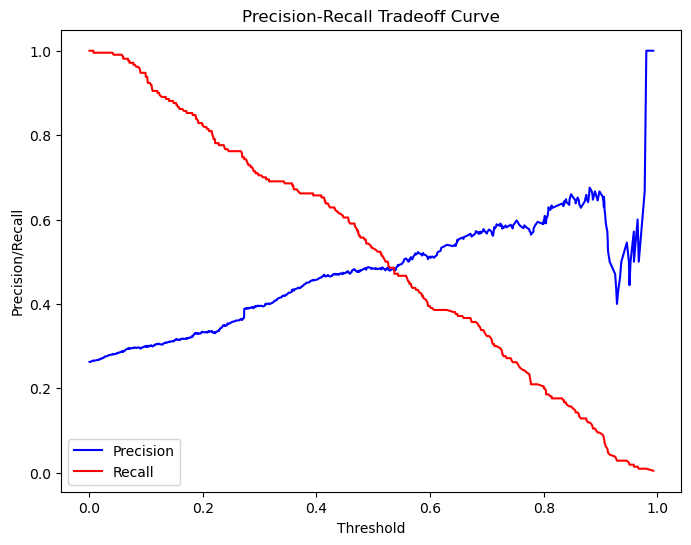

In [47]:
#Identifying further changes for best results like most optimal threshold value, n-estimators value etc and updating model with best parameters.

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Split the dataset again for this experiment (80/20 train-test split)
X_train, X_test, y_train, y_test = train_test_split(X_combined, df_train['toxic_label'], test_size=0.2, random_state=42)

# Initialize XGBoost with class weight to prioritize toxic class (class 1)
xgb_model = xgb.XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.2,
    max_depth=5,
    n_estimators=300,
    subsample=0.7,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])  # Class weight adjustment
)

# Train the model
xgb_model.fit(X_train, y_train)

# Get the probabilities for the test set
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Adjust the threshold and tune to improve recall for toxic comments
threshold = 0.3  # 
y_pred_adjusted = (y_pred_proba >= threshold).astype(int)

# Evaluate the model with adjusted threshold
print(f"Threshold: {threshold}")
print("Classification Report:")
print(classification_report(y_test, y_pred_adjusted))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_adjusted))

# Visualize Precision-Recall trade-off
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot Precision-Recall curve to decide on threshold tuning
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label="Precision", color="blue")
plt.plot(thresholds, recall[:-1], label="Recall", color="red")
plt.xlabel("Threshold")
plt.ylabel("Precision/Recall")
plt.title("Precision-Recall Tradeoff Curve")
plt.legend()
plt.show()

as we see that the threshold 0.5 model gave us low recall value for toxic comments, and the goal of this project is to identify the toxic comments, thus we change the threshold to a lower level such that the comments which are highly toxic are definately captured. this improved the recall to 70% which is significantly better than 33% of previous threshold. Thus we move ahead with the best parameters xgb model with 0.3 threshold for prediction. 

### Step 7 : Populating results using prediction model

In [57]:
#(pip install pickledb) incase of error for pickle
# Save the trained XGBoost model 
with open('/Users/arpitalonakadi/Downloads/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save the TF-IDF vectorizer
with open('/Users/arpitalonakadi/Downloads/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

In [60]:
import json
import pandas as pd
import pickle
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Assuming clean_text_with_sentiment_scores is already defined in your project
def preprocess_text(text):
    # Clean and preprocess text, emoji score, and VADER sentiment score
    cleaned_text, emoji_score, vader_score = clean_text_with_sentiment_scores(text)

    return cleaned_text, emoji_score, vader_score

# Load the test data
test_data_path = '/Users/arpitalonakadi/Downloads/z639_assignment1_test.json'  # Ensure the correct path
with open(test_data_path) as f:
    test_data = [json.loads(line) for line in f]

# Extract the text and platform_id from the test dataset
test_texts = [item['text'] for item in test_data]  # Original text column
platform_ids = [item['platform_id'] for item in test_data]

# Preprocess the texts to extract cleaned text, emoji scores, and VADER sentiment scores
preprocessed_texts, emoji_scores, vader_scores = zip(*[preprocess_text(text) for text in test_texts])

# Load the saved TF-IDF vectorizer
vectorizer_path = '/Users/arpitalonakadi/Downloads/tfidf_vectorizer.pkl'  # Ensure correct path
with open(vectorizer_path, 'rb') as f:
    vectorizer = pickle.load(f)

# Convert the preprocessed texts into TF-IDF vectors
X_test_tfidf = vectorizer.transform(preprocessed_texts)

# Combine the emoji scores and VADER sentiment scores into a DataFrame along with the TF-IDF vectors
X_test_combined = pd.DataFrame(X_test_tfidf.toarray())
X_test_combined['emoji_score'] = emoji_scores
X_test_combined['vader_score'] = vader_scores

# Load the trained XGBoost model (ensure the model is saved after training)
xgboost_model_path = '/Users/arpitalonakadi/Downloads/xgboost_model.pkl'  # Ensure correct path
with open(xgboost_model_path, 'rb') as f:
    xgboost_model = pickle.load(f)

# Make predictions using the pre-trained XGBoost model
predictions = xgboost_model.predict(X_test_combined)

# Convert predictions to Boolean values (True for toxic, False for non-toxic)
predictions_bool = predictions == 1  # Assuming 1 is toxic, 0 is non-toxic

# Create a DataFrame for submission in the required format
submission_df = pd.DataFrame({
    'platform_id': platform_ids,
    'prediction': predictions_bool
})

# Save the submission DataFrame as a CSV file
output_csv_path = '/Users/arpitalonakadi/Downloads/predictions.csv'  # Ensure correct path
submission_df.to_csv(output_csv_path, index=False)

print(f"Predictions saved to '{output_csv_path}'.")

Predictions saved to '/Users/arpitalonakadi/Downloads/predictions.csv'.
